### GOAL 
Notebook aims to disentangle HGSOC RNA data into 2+ data spaces (Cell Cycle Signal Space, Inteferon Signal Space, Cell Dissociation Signal Space, Cell Type Signal Space)

In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '../../'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding, visualize_2d

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# TODO - change path to actual data you care about
# TODO - debug getting HVG genes working with annotated dataframe
adata = sc.read_h5ad("../../../../data/synthetic/cophaser/synthethic_cc.h5ad")

In [5]:
adata.X = adata.layers["counts"]

In [6]:
adata.X

<10000x10097 sparse matrix of type '<class 'numpy.int64'>'
	with 34186412 stored elements in Compressed Sparse Row format>

##### Is the matrix sparse?

### Sanity-Checking the Data

### Pre-processing

In [7]:
adata.var["gene_symbols"] = adata.var.index

In [8]:
adata.var["gene_symbols"]

ANLN                ANLN
ANP32E            ANP32E
ATAD2              ATAD2
AURKA              AURKA
AURKB              AURKB
                 ...    
GENE_10092    GENE_10092
GENE_10093    GENE_10093
GENE_10094    GENE_10094
GENE_10095    GENE_10095
GENE_10096    GENE_10096
Name: gene_symbols, Length: 10097, dtype: object

In [9]:
genes_process_sinusodial = np.array(['ANLN', 'ANP32E', 'ATAD2', 'AURKA', 'AURKB', 'BIRC5', 'BLM', 'BRIP1',
       'BUB1', 'CASP8AP2', 'CBX5', 'CCNB2', 'CCNE2', 'CDC20', 'CDC25C',
       'CDC45', 'CDC6', 'CDCA2', 'CDCA3', 'CDCA7', 'CDCA8', 'CDK1', 'CENPA',
       'CENPE', 'CENPF', 'CENPU', 'CHAF1B', 'CKAP2', 'CKAP2L', 'CKAP5',
       'CKS1B', 'CKS2', 'CLSPN', 'CTCF', 'DLGAP5', 'DSCC1', 'DTL', 'E2F8',
       'ECT2', 'ESCO2', 'EXO1', 'G2E3', 'GAS2L3', 'GINS2', 'GMNN', 'GTSE1',
       'HELLS', 'HJURP', 'HMGB2', 'HMMR', 'JPT1', 'KIF11', 'KIF20B', 'KIF23',
       'KIF2C', 'LBR', 'MCM2', 'MCM4', 'MCM5', 'MCM6', 'MKI67', 'MSH2', 'NASP',
       'NCAPD2', 'NDC80', 'NEK2', 'NUF2', 'NUSAP1', 'PCNA', 'PIMREG', 'POLA1',
       'POLD3', 'PRIM1', 'PSRC1', 'RAD51', 'RAD51AP1', 'RANGAP1', 'RFC2',
       'RPA2', 'RRM1', 'RRM2', 'SLBP', 'SMC4', 'TACC3', 'TIPIN', 'TMPO',
       'TOP2A', 'TPX2', 'TTK', 'TUBB4B', 'TYMS', 'UBE2C', 'UBR7', 'UHRF1',
       'UNG', 'USP1', 'WDR76'])

In [12]:
adata.var["gene_symbols"]

ANLN                ANLN
ANP32E            ANP32E
ATAD2              ATAD2
AURKA              AURKA
AURKB              AURKB
                 ...    
GENE_10092    GENE_10092
GENE_10093    GENE_10093
GENE_10094    GENE_10094
GENE_10095    GENE_10095
GENE_10096    GENE_10096
Name: gene_symbols, Length: 10097, dtype: object

In [14]:
contained_genes_process_sinusodial = adata.var["gene_symbols"].isin(genes_process_sinusodial)

In [15]:
process_sinusodial_indices = np.where(contained_genes_process_sinusodial)[0]

all_known_indices = np.hstack((process_sinusodial_indices))  
remaining_indices = np.setdiff1d(np.arange(adata.shape[1]), all_known_indices)

rearranged_indices = np.hstack((process_sinusodial_indices, remaining_indices))
rearranged_indices = rearranged_indices.astype(int)

In [16]:
process_sinusodial_indices

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96])

In [14]:
rearranged_indices

array([  1,  20,  36,  56,  63,  79, 103, 108, 116, 126, 130, 144, 208,
       229, 230, 249, 255, 295, 297, 302, 308, 323, 324, 330, 340, 347,
       355, 360, 383, 422, 445, 448, 449, 464, 487, 498, 510, 511, 516,
       525, 526, 537, 539, 544, 555, 558, 577, 578, 606, 616, 633, 641,
       661, 665, 692, 697, 743, 752, 753, 759, 777, 782, 799, 800, 816,
       819, 841, 846, 862, 881, 888, 889, 898, 925, 942, 944, 958, 962,
       974, 980, 994,   0,   2,   3,   4,   5,   6,   7,   8,   9,  10,
        11,  12,  13,  14,  15,  16,  17,  18,  19,  21,  22,  23,  24,
        25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  57,  58,  59,  60,  61,  62,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  80,
        81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100, 101, 102, 104, 105, 10

In [17]:
adata = adata[:, rearranged_indices] # .copy() is safer in AnnData
adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_78676/3340023796.py:2: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["new_gene_ordering"] = rearranged_indices # NB: this takes a while to run!jj


### Pre-processing x2 - Calculating Gene Enrichment Scores

In [18]:
from anndata.utils import make_index_unique

# 1. Get the gene symbols and convert to a standard pandas Index
temp_index = pd.Index(adata.var['gene_symbols'].astype(str))

# 2. Use the anndata utility to make the index unique (appends -1, -2, etc. to duplicates)
adata.var_names = make_index_unique(temp_index)
adata.var_names.name = None

In [20]:
sc.tl.score_genes(
    adata,
    gene_list=genes_process_sinusodial,
    score_name="sinusodial_genes_enrichment_score"
)


### Model Configuration

In [21]:
model_name = "r2, e10"

In [22]:
from src.celluntangler.models.get_config import get_config
config = get_config()
config.model_name = model_name
config.seed = 68715
config.init = "custom"
config.max_epochs = 500 
config.epochs = 500

In [23]:
if config.seed:  
    torch.manual_seed(config.seed)
    np.random.seed(config.seed) 
    np.random.default_rng(config.seed)
components = utils.parse_components(model_name, config.fixed_curvature) 

### Creating Training Dataset

In [24]:
if not "batch" in adata.obs.columns.tolist(): 
    adata.obs["batch"] = adata.obs.index.str.split("_").str[0]
    adata.obs["batch"] = adata.obs["batch"].astype("category")

In [25]:
# One entry in n_batch for each "factor of batch effects"
config.n_batch = [1]

In [36]:
# Creating Training Dataset
x = adata.X.todense().astype(np.double)

In [37]:
# y holds the batch vector for the dataset
batch = (np.zeros((x.shape[0], 1)) * -1).astype(np.int64)
y = batch 
in_dim = x.shape[1]
print(f"in_dim = {in_dim}")
batch_size = config.batch_size
dataset = UMIVaeDataset(batch_size=batch_size, in_dim=in_dim)
print(f"dataset.in_dim = {dataset.in_dim}")
# Create the dataset loaders
train_loader = dataset.create_loaders(x, y, seed=config.seed)

in_dim = 10097
dataset.in_dim = 10097
Dataset seed: 68715


In [38]:
adata.var["gene_symbols"]

ANLN                ANLN
ANP32E            ANP32E
ATAD2              ATAD2
AURKA              AURKA
AURKB              AURKB
                 ...    
GENE_10092    GENE_10092
GENE_10093    GENE_10093
GENE_10094    GENE_10094
GENE_10095    GENE_10095
GENE_10096    GENE_10096
Name: gene_symbols, Length: 10097, dtype: object

In [39]:
# Creating (Disjoint) Masks
mask_sinusodial = np.zeros(adata.n_vars)
mask_sinusodial[adata.var["gene_symbols"].isin(genes_process_sinusodial)] = 1

mask_all = np.ones(adata.n_vars)
mask_all[adata.var["gene_symbols"].isin(genes_process_sinusodial)] = 0 

mask = torch.tensor([mask_sinusodial, mask_all])

In [40]:
mask

tensor([[1., 1., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 1., 1., 1.]], dtype=torch.float64)

In [41]:
adata.X.shape

(10000, 10097)

In [42]:
sinusodial_genes_potentially = adata.X[:,mask_sinusodial.astype(bool)]

In [43]:
sinusodial_genes_potentially

<10000x97 sparse matrix of type '<class 'numpy.int64'>'
	with 513992 stored elements in Compressed Sparse Row format>

In [44]:
X = sinusodial_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

In [51]:
mask_sinusodial

array([1., 1., 1., ..., 0., 0., 0.])

In [78]:
z = np.reshape(z, (-1, 1))

In [85]:
z.shape

(10000, 1)

In [84]:
pc1.shape

(10000, 1)

In [89]:
pc1.ravel().shape

(1, 10000)

In [95]:
np.array(pc1).flatten().shape

(10000,)

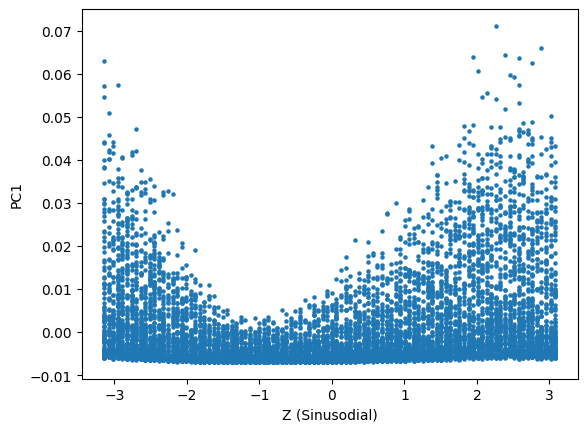

In [96]:
z = adata.obs["cell_cycle_phase"].to_numpy()
plt.scatter(z, np.array(pc1).flatten(), s=5)
plt.xlabel("Z (Sinusodial)")
plt.ylabel("PC1")
plt.show()

In [71]:
mask_monotonic = np.zeros(adata.n_vars)
mask_monotonic[adata.var["gene_symbols"].isin(genes_process_monotonic)] = 1
monotone_genes_potentially = adata.X[:,mask_monotonic.astype(bool)]

X = monotone_genes_potentially
X = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(X, full_matrices=False)
pc1 = U[:, 0]

z = adata.obsm['ground_truth_z'][:,0]
plt.scatter(z, pc1, s=5)
plt.xlabel("Z (Monotonic)")
plt.ylabel("PC1")

NameError: name 'genes_process_monotonic' is not defined

In [32]:
adata.var

,perfect_order,gene_symbols
661,136,661
805,156,805
710,143,710
420,118,420
1,89,1
...,...,...
613,682,613
916,83,916
986,987,986
64,222,64


In [66]:
adata.uns['affected_genes']

{'0': array(['287', '828', '172', '290', '906', '456', '765', '973', '380',
        '854', '422', '358', '528', '434', '489', '608', '349', '831',
        '62', '689', '647', '536', '153', '541', '432', '809', '916',
        '264', '157', '598', '296', '272', '818', '966', '205', '610',
        '135', '921', '74', '753', '461', '586', '790', '194', '155',
        '303', '631', '6', '638', '850', '42', '127', '970', '546', '469',
        '670', '104', '962', '147', '550', '359', '307', '18', '500', '28',
        '95', '88', '212', '0', '124', '604', '857', '140', '738', '614',
        '97', '773', '591', '894', '611', '258', '889', '143', '644',
        '561', '862', '198', '201', '284'], dtype=object),
 '1': array(['299', '217', '447', '458', '76', '78', '173', '597', '698', '694',
        '949', '742', '803', '755', '676', '36', '145', '871', '221', '31',
        '805', '746', '357', '712', '526', '992', '420', '534', '410',
        '286', '539', '101', '553', '322', '783', '1', '16',

In [33]:
adata.X

array([[ 1,  1,  1, ...,  0,  0,  0],
       [ 1, 15,  7, ...,  0,  0, 10],
       [38, 30,  1, ...,  0,  0,  0],
       ...,
       [ 3, 14, 72, ...,  0,  0,  0],
       [ 7, 11,  7, ...,  0,  0,  0],
       [ 5, 62,  6, ..., 14,  0,  0]])

In [63]:
adata

AnnData object with n_obs × n_vars = 6000 × 1000
    obs: 'pert', 'perfect_order', 'sinusodial_genes_enrichment_score', 'monotonic_genes_enrichment_score', 'batch'
    var: 'perfect_order', 'gene_symbols'
    uns: 'affected_genes', 'log1p', 'neighbors', 'pca', 'pert_colors', 'umap', 'new_gene_ordering'
    obsm: 'X_pca', 'X_umap', 'ground_truth_identity', 'ground_truth_z'
    varm: 'PCs', 'ground_truth_effect'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [40]:
adata.obsm['ground_truth_identity'].shape

array([[0., 1.],
       [1., 0.],
       [1., 1.],
       ...,
       [1., 1.],
       [1., 0.],
       [0., 0.]])

In [43]:
adata.obsm['ground_truth_identity'][:,1]

array([1., 0., 1., ..., 1., 0., 0.])

In [41]:
adata.obsm['ground_truth_identity'].shape

(6000, 2)

In [65]:
adata.obsm['ground_truth_z']

array([[0.        , 0.25365049],
       [0.74341684, 0.        ],
       [0.87728848, 0.13594148],
       ...,
       [0.93108928, 0.5472905 ],
       [0.60824711, 0.        ],
       [0.        , 0.        ]])

In [38]:
adata.varm['ground_truth_effect']

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]])

### Configure Save Paths

In [98]:
epoch_embeddings_save_path = "/Users/jeromecho/onedrive/Thesis/thesis/results/benchmarking/synthetic/02_03_experiment_set_1/celluntangler_r2_e10/cophaser"
visualize_information={}
# The epochs to save the intermediate embeddings for
visualize_information["epochs"]=[i for i in range(0, 500, 50)] 
visualize_information["x"]=x
visualize_information["y"]=y
visualize_information["embeddings_save_path"]=epoch_embeddings_save_path
visualize_information["model_name"]=config.model_name
visualize_information["device"]=config.device

### Model Creation

In [99]:
use_gpu = False
if use_gpu:
  print("Using GPU")
  config.device = torch.device("cuda")
else:
  print("Using CPU")
  config.device = torch.device("cpu")

Using CPU


In [100]:
torch.set_default_dtype(torch.float64)

In [101]:
model = NBVAE(h_dim=config.h_dim,
              components=components,
              mask=mask,
              dataset=dataset,
              config=config).to(config.device)

Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
Linear(in_features=32, out_features=2, bias=True)
initializing Xavier uniform weights in Linear
RotatedHyperbolicComponent(R^3)


In [68]:
adata.uns

{'affected_genes': {'0': array(['287', '828', '172', '290', '906', '456', '765', '973', '380',
         '854', '422', '358', '528', '434', '489', '608', '349', '831',
         '62', '689', '647', '536', '153', '541', '432', '809', '916',
         '264', '157', '598', '296', '272', '818', '966', '205', '610',
         '135', '921', '74', '753', '461', '586', '790', '194', '155',
         '303', '631', '6', '638', '850', '42', '127', '970', '546', '469',
         '670', '104', '962', '147', '550', '359', '307', '18', '500', '28',
         '95', '88', '212', '0', '124', '604', '857', '140', '738', '614',
         '97', '773', '591', '894', '611', '258', '889', '143', '644',
         '561', '862', '198', '201', '284'], dtype=object),
  '1': array(['299', '217', '447', '458', '76', '78', '173', '597', '698', '694',
         '949', '742', '803', '755', '676', '36', '145', '871', '221', '31',
         '805', '746', '357', '712', '526', '992', '420', '534', '410',
         '286', '539', '101',

### Training

In [102]:
trainer = Trainer(model)

optimizer = trainer.build_optimizer(learning_rate=config.learning_rate,
                                        fixed_curvature=config.fixed_curvature,
                                        use_adamw=config.use_adamw,
                                        weight_decay=config.weight_decay)

betas = utils.linear_betas(config.start,
                           config.end,
                           end_epoch=config.end_epoch,
                           epochs=config.epochs)


trainer.train_epochs(optimizer=optimizer,
                       train_data=train_loader,
                       betas=betas,
                       likelihood_n=0,
                       max_epochs=config.max_epochs,
                       visualize_information=visualize_information)

initialized early stopper
	TrainEpoch 0:	

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'bce': -9499.449, 'kl': 52.574, 'elbo': -9552.023, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 1:	{'bce': -8401.236, 'kl': 27.207, 'elbo': -8428.442, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 2:	{'bce': -8357.619, 'kl': 22.234, 'elbo': -8379.853, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 3:	{'bce': -8311.356, 'kl': 21.047, 'elbo': -8332.403, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 4:	{'bce': -8299.569, 'kl': 19.649, 'elbo': -8319.217, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'beta': 1.0, 'comp_000_r2/curvature': -2.0, 'comp_001_e10/curvature': 0.0}
	TrainEpoch 5:	{'bce': -8294.666, 'kl': 18.198, 'elbo': -8312.864, 'll': 0.0, 'mi': 0.0, 'cov_norm': 0.0, 'bet

### Saving Embeddings

In [103]:
embeddings_save_path = epoch_embeddings_save_path

In [104]:
checkpoint = torch.load(
    os.path.join(embeddings_save_path,  f"{model_name}_best_model.pt"),
    map_location=config.device
)
model.load_state_dict(checkpoint["model_state"])
model.eval()

NBVAE(
  (components): ModuleList(
    (0): RotatedHyperbolicComponent(R^3)
    (1): EuclideanComponent(R^10)
  )
  (encoder): Sequential(
    (0): Linear(in_features=10097, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): GELU(approximate='none')
  )
  (decoder): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): GELU(approximate='none')
  )
  (fc_mu): Linear(in_features=128, out_features=10097, bias=True)
  (fc_sigma): Linear(in_features=128, out_features=10097, bias=True)
)

In [105]:
a = model(torch.log1p(torch.tensor(x, device=config.device)), torch.tensor(y, device=config.device))
np.savetxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'), a[4].detach().to(torch.device("cpu")).numpy())

### Analysis

In [106]:
gene_expression_matrix_path = epoch_embeddings_save_path

In [107]:
embeddings = np.loadtxt(os.path.join(embeddings_save_path, f'{model_name}_all_encode_v63_z_params_best.txt'))
component_embeddings = split_embeddings(model_name, embeddings)
for c in component_embeddings:
    adata.obsm[c] = component_embeddings[c]

r2 3
e10 10


#### Visualization of Component 1 (R2)

In [111]:
adata.obs

,latent_coordinate,cell_cycle_phase,sinusodial_genes_enrichment_score,batch
0,0.0000,-1.005310,3.530765,0
1,0.0001,-3.141593,31.395224,1
2,0.0002,-3.141593,27.285163,2
3,0.0003,-0.879646,4.431300,3
4,0.0004,0.188496,10.869710,4
...,...,...,...,...
9995,0.9996,2.450442,3.419352,9995
9996,0.9997,0.314159,-0.061401,9996
9997,0.9998,-1.696460,-0.892071,9997
9998,0.9999,2.261947,2.284734,9998


/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler/src/visualization/visualization_functions.py:266: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=bbox_to_anchor)


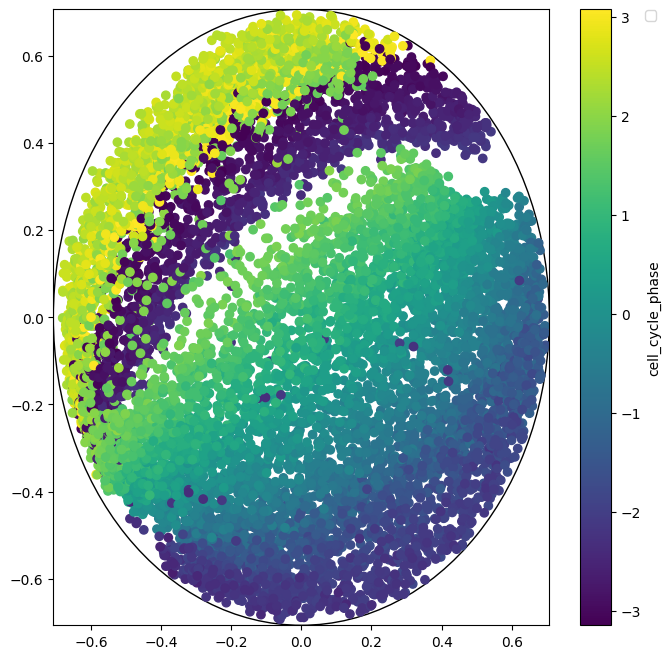

In [110]:
embeddings_key = "component1_r2"
desired_obs = 'cell_cycle_phase'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label=desired_obs,
                      bbox_to_anchor=legend_coordinates)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/CellUntangler/src/visualization/visualization_functions.py:266: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', bbox_to_anchor=bbox_to_anchor)


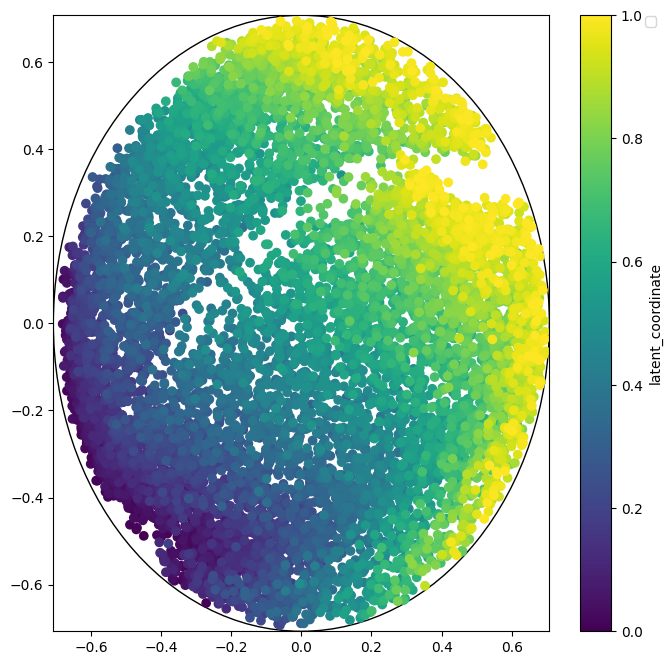

In [112]:
embeddings_key = "component1_r2"
desired_obs = 'latent_coordinate'
desired_obs_all = adata.obs[desired_obs]
legend_coordinates = (1.23,1.01)
fig = visualize_poincare_from_lorentz(adata.obsm[embeddings_key],
                       desired_obs_all,
                       curvature=-2,
                      embedding_type='continuous',
                       cmap=plt.cm.viridis,
                       cat_colors=None,
                      grid_lines=True,
                      c_bar_label=desired_obs,
                      bbox_to_anchor=legend_coordinates)

Text(0.5, 1.0, 'Sinusodial Genes Enrichment Score Distribution')

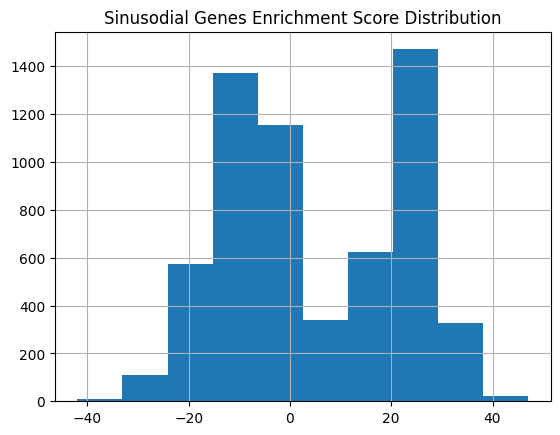

In [54]:
ax = adata.obs["sinusodial_genes_enrichment_score"].hist()
ax.set_title("Sinusodial Genes Enrichment Score Distribution")

#### Visualization of Component 2 (E2)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


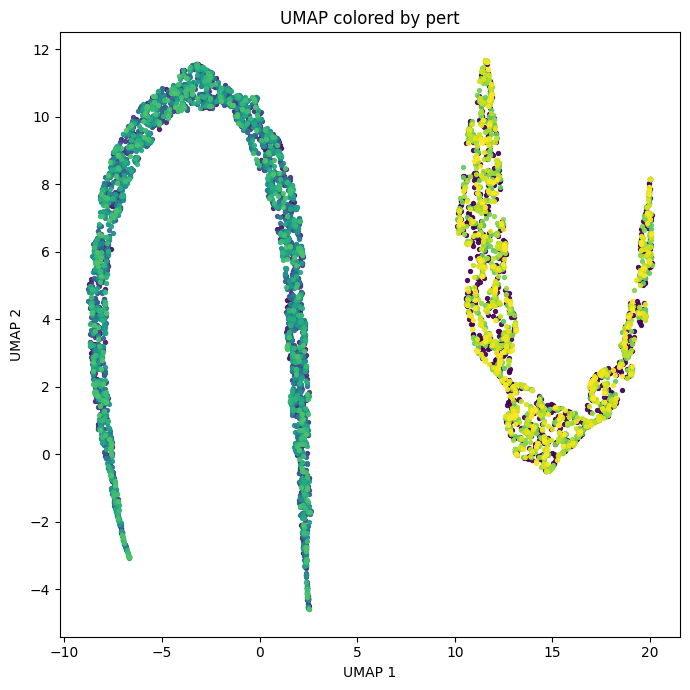

In [50]:
embeddings_key = "component2_e10"
desired_obs = 'pert'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


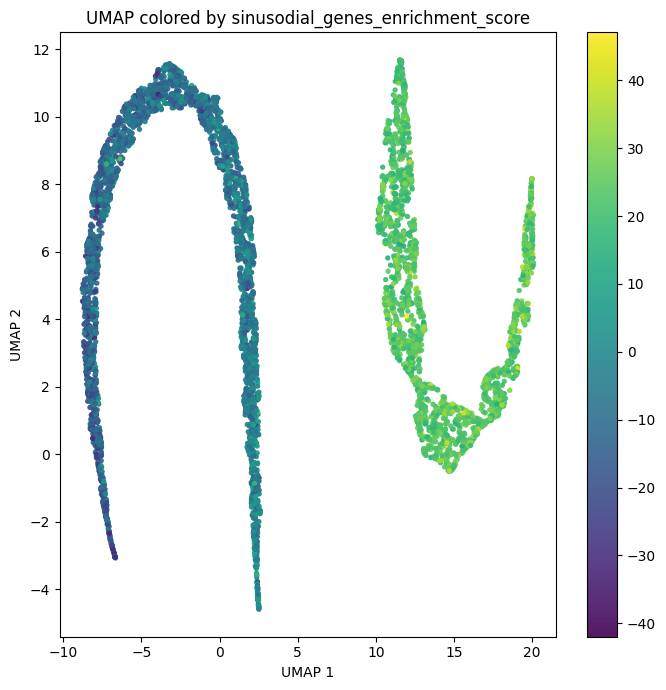

In [51]:
embeddings_key = "component2_e10"
desired_obs = 'sinusodial_genes_enrichment_score'

visualize_embedding(
    embedding=adata.obsm[embeddings_key],
    obs_values=adata.obs[desired_obs],
    point_size=8,
    alpha=0.9,
    figsize=(7,7),
    show_legend=False
)